In [1513]:
!pwd

/Users/flaviaschneider/Documents/flavia/Data_GEOBIA/notebooks


# Notebook para testar as métricas de Intra e Inter cluster
26/04/2024

In [945]:
import numpy as np
from math import ceil

from skimage.color import rgb2gray
from skimage.filters import sobel
from skimage.segmentation import slic
from skimage.segmentation import mark_boundaries
from skimage.util import img_as_float

import imageio.v2 as imageio
from skimage.measure import regionprops, regionprops_table
import pandas as pd
import psutil
import time
import sys
import os
import glob

from itertools import product

import pickle
import random
from tqdm import tqdm

from sklearn_extra.cluster import CLARA

from sklearn.metrics import silhouette_samples, silhouette_score, pairwise_distances_chunked
from sklearn.preprocessing import LabelEncoder
import functools
from scipy.sparse import issparse

import dask.array as da
import dask.dataframe as dd 

import matplotlib.pyplot as plt
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MaxNLocator, FormatStrFormatter
from matplotlib.colorbar import Colorbar

import plotly.express as px
import plotly.graph_objects as go

from sklearn.datasets import make_blobs

import multiprocessing
nproc = multiprocessing.cpu_count()-2


In [952]:
def optimal_number_of_clusters(wcss,min_cl, max_cl):
    import math
    x1, y1 = min_cl, wcss[0]
    x2, y2 = max_cl, wcss[len(wcss)-1]

    distances = []
    for i in range(len(wcss)):
        x0 = i+2
        y0 = wcss[i]
        numerator = abs((y2-y1)*x0 - (x2-x1)*y0 + x2*y1 - y2*x1)
        denominator = math.sqrt((y2 - y1)**2 + (x2 - x1)**2)
        distances.append(numerator/denominator)
    
    return distances.index(np.max(distances)) + min_cl

In [962]:
def _silhouette_reduce(D_chunk, start, labels, label_freqs):
    """Accumulate silhouette statistics for vertical chunk of X.

    Parameters
    ----------
    D_chunk : {array-like, sparse matrix} of shape (n_chunk_samples, n_samples)
        Precomputed distances for a chunk. If a sparse matrix is provided,
        only CSR format is accepted.
    start : int
        First index in the chunk.
    labels : array-like of shape (n_samples,)
        Corresponding cluster labels, encoded as {0, ..., n_clusters-1}.
    label_freqs : array-like
        Distribution of cluster labels in ``labels``.
    """
    n_chunk_samples = D_chunk.shape[0]
    # accumulate distances from each sample to each cluster
    cluster_distances = np.zeros(
        (n_chunk_samples, len(label_freqs)), dtype=D_chunk.dtype
    )

    if issparse(D_chunk):
        if D_chunk.format != "csr":
            raise TypeError(
                "Expected CSR matrix. Please pass sparse matrix in CSR format."
            )
        for i in range(n_chunk_samples):
            indptr = D_chunk.indptr
            indices = D_chunk.indices[indptr[i] : indptr[i + 1]]
            sample_weights = D_chunk.data[indptr[i] : indptr[i + 1]]
            sample_labels = np.take(labels, indices)
            cluster_distances[i] += np.bincount(
                sample_labels, weights=sample_weights, minlength=len(label_freqs)
            )
    else:
        for i in range(n_chunk_samples):
            sample_weights = D_chunk[i]
            sample_labels = labels
            cluster_distances[i] += np.bincount(
                sample_labels, weights=sample_weights, minlength=len(label_freqs)
            )

    # intra_index selects intra-cluster distances within cluster_distances
    end = start + n_chunk_samples
    intra_index = (np.arange(n_chunk_samples), labels[start:end])
    # intra_cluster_distances are averaged over cluster size outside this function
    intra_cluster_distances = cluster_distances[intra_index]
    # of the remaining distances we normalise and extract the minimum
    cluster_distances[intra_index] = np.inf
    cluster_distances /= label_freqs
    inter_cluster_distances = cluster_distances.min(axis=1)
    return intra_cluster_distances, inter_cluster_distances


In [963]:
#calculate intra and inter cluster of n_opt
def calc_inter_intra_cluster(arraybands_sel, dic_cluster, n_opt):
    
    le = LabelEncoder()
    labels = le.fit_transform(dic_cluster[n_opt])
    n_samples = len(labels)
    label_freqs = np.bincount(labels)
    # check_number_of_labels(len(le.classes_), n_samples)
    
    metric = "euclidean"
    kwds = {}
    
    kwds["metric"] = metric
    reduce_func = functools.partial(
        _silhouette_reduce, labels=labels, label_freqs=label_freqs
    )
    results = zip(*pairwise_distances_chunked(arraybands_sel, reduce_func=reduce_func, **kwds))
    intra_clust_dists, inter_clust_dists = results
    intra_clust_dists = np.concatenate(intra_clust_dists)
    inter_clust_dists = np.concatenate(inter_clust_dists)
    
    df = pd.DataFrame({'label': labels, 'inter': inter_clust_dists, 'intra': intra_clust_dists })
    return df

In [981]:
import dask.array as da
import dask.dataframe as dd 

def gen_matrix_sim_da(n_grupo,dic_cluster, perc=1, chunks=1000):
    ''''
    gen matriz similarity dask
    '''
    n_ini=2
    max_n=len(dic_cluster.keys())
    
    #n_selected = list(range(n_ini,ceil(n_opt*1.2)+1))
    n_selected = list(range(n_ini,ceil(max_n*perc)+1))
    
    #n_selected = [2,3,4]
    time_ini = time.time()
    for i, n in enumerate(n_selected):
        
        da_arr = da.from_array(np.array(dic_cluster[n]),chunks=chunks)
        if (i==0):
            matrix_sim = (da_arr[:, None] == da_arr[None, :]).astype(int)
            continue
        matrix_sim = (da_arr[:, None] == da_arr[None, :]).astype(int)+matrix_sim
    matrix_sim=matrix_sim/len(n_selected)    
    time_fim = time.time()
    print (time_fim-time_ini)
    
    return matrix_sim

In [950]:
arraybands_sel, y = make_blobs(n_samples=15, random_state=42)

In [959]:
n_clusters=8 
dic_cluster={}
sse=[]
time_i = time.time()
for n in range (2, n_clusters+1):
    #clara = timedcall(CLARA(n_clusters=n, random_state=0).fit(arraybands_sel))
    time_ini = time.time()
    clara = CLARA(n_clusters=n,n_sampling=40+2*n,n_sampling_iter=5, random_state=0).fit(arraybands_sel)
    #Preciso entender se precisa fazer o predict, entender a diferenca de fazer o predict
    #clusters_sel = clara.predict(arraybands_sel)
    clusters_sel = clara.labels_
    time_fim = time.time()
    #print (f'tempo de execucao para {n}: {time_fim-time_ini}')
    #15/02/2024: nao me lembro pq preciso fazer o get_labels aqui
    # labels_sel = get_labels(clusters_sel.tolist(), len(arraybands_sel))
    # dic_cluster[n] = labels_sel
    dic_cluster[n] = clusters_sel.tolist()
    sse.append(clara.inertia_)
    #adiciona a info do cluster no df
    #props_df_sel[id_test]['cluster_'+str(n)]= labels_sel[props_df_sel[id_test].index]

    #props_df_sel[id_test]['cluster_'+str(n)]=clusters_sel
time_f = time.time()
print (f'tempo de execucao total Clara: {time_f-time_i}')

tempo de execucao total Clara: 0.06036019325256348


In [960]:
n_opt = optimal_number_of_clusters(sse, 2, n_clusters)
n_opt

3

In [961]:
dic_cluster[n_opt]

[2, 2, 0, 1, 0, 1, 0, 2, 1, 2, 0, 1, 0, 1, 2]

In [965]:
df = calc_intra_inter_df(arraybands_sel, dic_cluster, n_opt)


In [979]:
df.shape, df.head(2)

((15, 3),
    label      inter      intra
 0      2   9.958766  11.004405
 1      2  10.307429   6.269774)

In [980]:
result = df.groupby('label').agg({'inter':['max', 'min','median', 'mean', 'std'],'intra':['max', 'min','median', 'mean', 'std']})
result

inter                                                 intra  \
             max        min     median       mean       std        max   
label                                                                    
0      11.252665   9.058129  10.414310  10.261125  0.950276   9.070187   
1      14.822132  13.600493  14.741944  14.426715  0.520162  10.075371   
2      11.188936   8.819094  10.307429  10.261125  0.952257  11.004405   

                                               
            min    median      mean       std  
label                                          
0      5.767833  6.824291  7.021043  1.231939  
1      5.673807  6.808854  7.530154  1.744793  
2      6.269774  8.885392  8.601410  1.863269

In [977]:
df_array= pd.DataFrame(arraybands_sel, columns=['X','Y'])
df_array['cor'] = dic_cluster[n_opt]
df_array["cor"] = df_array["cor"].astype(str)
df_array.head(2)

,X,Y,cor
0,-0.929985,9.781721,2
1,-2.972615,8.548556,2


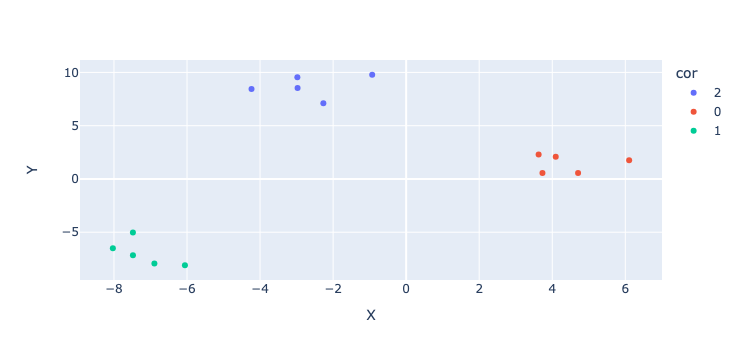

In [978]:
cl_map='tab20'
cl = plt.get_cmap(cl_map)
fig = px.scatter(df_array, x='X', y="Y", color="cor")
fig.show()

In [982]:
matrix_sim_dask = gen_matrix_sim_da(n_opt, dic_cluster)
matrix_sim_dask

0.04526495933532715


dask.array<truediv, shape=(15, 15), dtype=float64, chunksize=(15, 15), chunktype=numpy.ndarray>

In [985]:
matrix_sim.compute(), len(dic_cluster.keys())

(array([[1.        , 0.27272727, 1.        , ..., 0.27272727, 0.27272727,
         0.27272727],
        [0.27272727, 1.        , 0.27272727, ..., 1.        , 0.72727273,
         0.72727273],
        [1.        , 0.27272727, 1.        , ..., 0.27272727, 0.27272727,
         0.27272727],
        ...,
        [0.27272727, 1.        , 0.27272727, ..., 1.        , 0.72727273,
         0.72727273],
        [0.27272727, 0.72727273, 0.27272727, ..., 0.72727273, 1.        ,
         0.90909091],
        [0.27272727, 0.72727273, 0.27272727, ..., 0.72727273, 0.90909091,
         1.        ]]),
 7)

In [989]:
matrix_sim=matrix_sim_dask.compute()
matrix_dist = 1- matrix_sim


In [990]:
#cluster using a distance matrix
#from sklearn_extra.cluster import KMedoids

dic_cluster_ms ={}
sse_ms=[]
t_ini = time.time()
for n in range (2, n_clusters+1):
    time_ini = time.time()    
    #clusters_sel_d = clara.predict(arraybands_sel)
    cl_d = CLARA(n_clusters=n, n_sampling=40+2*n, n_sampling_iter=5, random_state=0)
    #clara_ms = cl_d.fit(matrix_dist_dask)
    clara_ms = cl_d.fit(matrix_dist)
    dic_cluster_ms[n] = clara_ms.labels_
    
    time_fim = time.time()
    print (f'tempo de execucao para {n}: {time_fim-time_ini}')
    #15/02/2024: nao me lembro pq preciso fazer o get_lebels aqui
    # labels_sel = get_labels(clusters_sel.tolist(), len(arraybands_sel))
    # dic_cluster[n] = labels_sel
    # dic_cluster_d[n] = clusters_sel_d.tolist()
    
    sse_ms.append(clara_ms.inertia_)
    
    #adiciona a info do cluster no df
    #props_df_sel[id_test]['cluster_'+str(n)]= labels_sel[props_df_sel[id_test].index
    #props_df_sel[id_test]['cluster_'+str(n)]=clusters_sel

t_fim = time.time()
print (f'tempo de execucao cluster CLARA total : {t_fim-t_ini}')

tempo de execucao para 2: 0.04124093055725098
tempo de execucao para 3: 0.004780769348144531
tempo de execucao para 4: 0.0033159255981445312
tempo de execucao para 5: 0.004271030426025391
tempo de execucao para 6: 0.0033631324768066406
tempo de execucao para 7: 0.0030112266540527344
tempo de execucao para 8: 0.002740144729614258
tempo de execucao cluster CLARA total : 0.06352806091308594


In [991]:
n_opt_ms = optimal_number_of_clusters(sse_ms, 2, n_clusters)
n_opt_ms

4

In [992]:
time_i = time.time()
df_ms= calc_inter_intra_cluster(matrix_dist, dic_cluster_ms, n_opt_ms)
time_f = time.time()
print (f'tempo calculo inter e intra cluster: {time_f-time_i}')
df_ms = df_ms.rename(columns={'inter':'inter_ms', 'intra': 'intra_ms'})
df_ms.head(2)

tempo calculo inter e intra cluster: 0.006094932556152344


,label,inter_ms,intra_ms
0,3,1.615893,4.472136
1,3,2.088327,1.118034


In [995]:
result_ms = df_ms.groupby('label').agg({'inter_ms':['max', 'min','median', 'mean', 'std'],'intra_ms':['max', 'min','median', 'mean', 'std']})
result_ms

inter_ms                                          intra_ms            \
            max       min    median      mean       std       max       min   
label                                                                         
0      1.400669  1.400669  1.400669  1.400669  0.000000  0.000000  0.000000   
1      2.522124  2.409472  2.522124  2.477063  0.061702  2.236068  1.490712   
2      1.424001  1.354006  1.424001  1.400669  0.040411  0.577350  0.288675   
3      2.088327  1.615893  2.088327  1.993841  0.211279  4.472136  1.118034   

                                     
         median      mean       std  
label                                
0      0.000000  0.000000  0.000000  
1      1.490712  1.788854  0.408248  
2      0.288675  0.384900  0.166667  
3      1.118034  1.788854  1.500000

In [1000]:
df_array_ms= pd.DataFrame(arraybands_sel, columns=['X','Y'])
df_array_ms['cor'] = dic_cluster_ms[n_opt_ms]
df_array_ms["cor"] = df_array_ms["cor"].astype(str)
df_array_ms.head(2)

,X,Y,cor
0,-0.929985,9.781721,3
1,-2.972615,8.548556,3


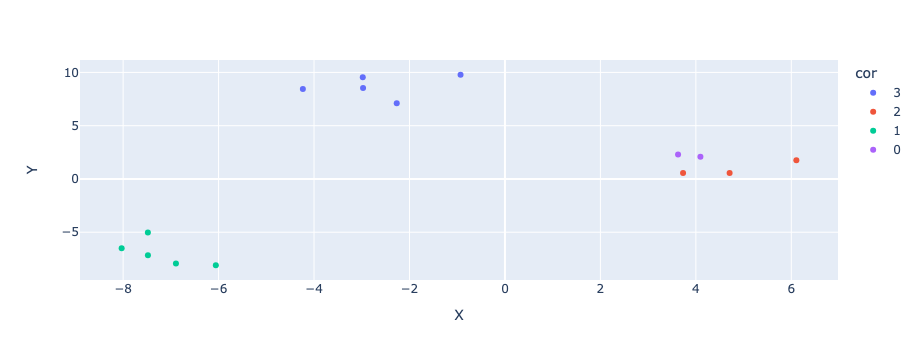

In [1001]:
fig = px.scatter(df_array_ms, x='X', y="Y", color="cor")
fig.show()

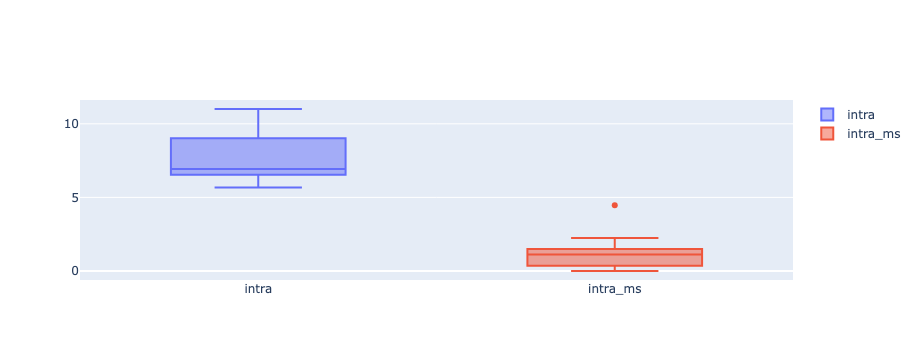

In [1002]:
fig = go.Figure()
fig.add_trace(go.Box(y=df["intra"],name='intra'))
fig.add_trace(go.Box(y=df_ms["intra_ms"], name = 'intra_ms'))

fig.show()